# Đổi một feature thì giá *diễn biến* thế nào — đường phản ứng

> **Mentor nói:** *"Khi mình thay đổi 1 feature thì price sẽ **diễn biến** thế nào… Ở các version
> pricing của bọn anh từ market signal multiplier đến personalized multiplier thì bọn anh đều
> measure price như là kết quả của một thay đổi của yếu tố thị trường."*

`04_CAU_THANH_GIA` trả lời *"đổi một yếu tố thì giá đổi **bao nhiêu**"* — mỗi yếu tố một con số.
Notebook này trả lời câu tiếp theo: **đổi bao nhiêu thì giá đổi bao nhiêu**, tức **hình dạng** của
quan hệ.

Ba câu hỏi một con số không trả lời được:

| Câu hỏi | Vì sao quan trọng |
|---|---|
| Quan hệ **tuyến tính** hay có độ cong? | Quyết định có ngoại suy được không |
| Có **ngưỡng nhảy bậc** không? | Nếu có → dùng được Regression Discontinuity để ước lượng nhân quả sạch |
| **Độ co giãn** bao nhiêu? | Con số duy nhất so sánh được giữa các yếu tố khác đơn vị |

> ⚠️ **Dữ liệu synthetic** — mọi kết quả mô tả hành vi bộ sinh dữ liệu, không phải thị trường thật.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BASE, MULT, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                       "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

COLS = ["target_request_id", "target_timestamp", "service_name", "weather_main",
        "pickup_location_name", "dropoff_location_name",
        "quote_distance", "quote_duration", "gio_vn", "target_is_weekend",
        "pricing_demand_index_5m_lag", "pricing_supply_index_5m_lag",
        "pricing_market_imbalance_5m_lag", "pricing_quote_count_5m_lag",
        "target_shown_price", "target_shown_multiplier", "requested_lag_minutes"]

d = pd.read_parquet(DATA, columns=COLS).drop_duplicates("target_request_id")
d["gia"]  = d.target_shown_price
d["heso"] = d.target_shown_multiplier
d["base"] = d.gia / d.heso
d["cuoi_tuan"] = d.target_is_weekend.astype(bool)
d["mua"]  = d.weather_main == "Rain"
d["kmh"]  = d.quote_distance / (d.quote_duration / 3600)   # duration tinh bang GIAY
d["kmb"]  = (d.quote_distance // 1).astype(int)

print(f"{len(d):,} chuyến độc lập")
print(f"Giá TB {d.gia.mean():,.0f}đ = giá cơ bản {d.base.mean():,.0f}đ × hệ số {d.heso.mean():.3f}")

1,724,714 chuyến độc lập
Giá TB 121,367đ = giá cơ bản 103,642đ × hệ số 1.165


## 1. Phương pháp — đường phản ứng có khống chế

Mở rộng phép ghép cặp ở `04` từ **hai nhóm** lên **nhiều mức**:

1. Chia yếu tố đang xét thành `k` mức (thập phân vị hoặc bin cố định)
2. Chia phần còn lại thành các **ô** khống chế
3. Trong mỗi ô, lấy giá trung bình của từng mức
4. Chuẩn hoá theo **mức tham chiếu** của chính ô đó → được đường phản ứng tương đối
5. Bình quân các ô theo số chuyến

Bước 4 là mấu chốt: mỗi ô tự làm đối chứng cho chính nó, nên chênh lệch giữa các ô (ô toàn chuyến
dài thì giá cao hơn) không làm lệch kết quả.

In [2]:
def duong_phan_ung(yeu_to, khong_che, muc_goc, cot="gia", df=None):
    """Duong phan ung tuong doi cua `cot` theo `yeu_to`, khong che `khong_che`.

    Tra ve Series: gia tri = % thay doi so voi muc_goc, index = cac muc cua yeu_to.
    """
    df = d if df is None else df
    g = (df.groupby(khong_che + [yeu_to], observed=True)[cot]
           .agg(["mean", "size"]).unstack(yeu_to))
    g = g.dropna()                                   # chi giu o co DU moi muc
    n = g["size"].sum(axis=1)
    w = n / n.sum()
    goc = g[("mean", muc_goc)]
    ket = {m: float(((g[("mean", m)] / goc - 1) * w).sum()) for m in g["mean"].columns}
    kq = pd.Series(ket)
    kq.attrs["so_o"] = len(g)
    kq.attrs["n"] = int(n.sum())
    return kq

# Kiem nhanh: chay lai hieu ung mua o notebook 04 -> phai khop
d["mua_b"] = d.mua
test = duong_phan_ung("mua_b", ["kmb", "gio_vn", "cuoi_tuan"], False)
print(f"Kiểm chứng — hiệu ứng mưa: {test[True]:+.2%}  "
      f"({test.attrs['so_o']:,} ô, {test.attrs['n']:,} chuyến)")
print("(khớp với 04_CAU_THANH_GIA thì hàm chạy đúng)")

Kiểm chứng — hiệu ứng mưa: +9.72%  (1,050 ô, 1,724,332 chuyến)
(khớp với 04_CAU_THANH_GIA thì hàm chạy đúng)


## 2. Cung–cầu — yếu tố mạnh nhất, xem kỹ hình dạng

`04` chia 5 nhóm và thấy Q1 → Q5 là **+35,1%**. Ở đây chia **10 nhóm thập phân vị** để nhìn được
độ cong, và tách riêng ba tín hiệu thị trường.

In [3]:
KC = ["kmb", "gio_vn", "weather_main"]
TIN_HIEU = [("Mất cân đối (cầu/cung)", "pricing_market_imbalance_5m_lag"),
            ("Chỉ số cầu",             "pricing_demand_index_5m_lag"),
            ("Chỉ số cung",            "pricing_supply_index_5m_lag")]

DPU = {}
for ten, cot in TIN_HIEU:
    d["_q"] = pd.qcut(d[cot], 10, labels=[f"D{i}" for i in range(1, 11)])
    DPU[ten] = {
        "gia":  duong_phan_ung("_q", KC, "D1", "gia"),
        "base": duong_phan_ung("_q", KC, "D1", "base"),
        "heso": duong_phan_ung("_q", KC, "D1", "heso"),
        "muc":  d.groupby("_q", observed=True)[cot].mean(),
    }
    print(f"{ten:24} D1→D10: {DPU[ten]['gia']['D10']:+7.2%}   "
          f"({DPU[ten]['gia'].attrs['so_o']:,} ô)")

Mất cân đối (cầu/cung)   D1→D10: +50.56%   (306 ô)


Chỉ số cầu               D1→D10: +34.28%   (72 ô)


Chỉ số cung              D1→D10: -18.26%   (1,020 ô)


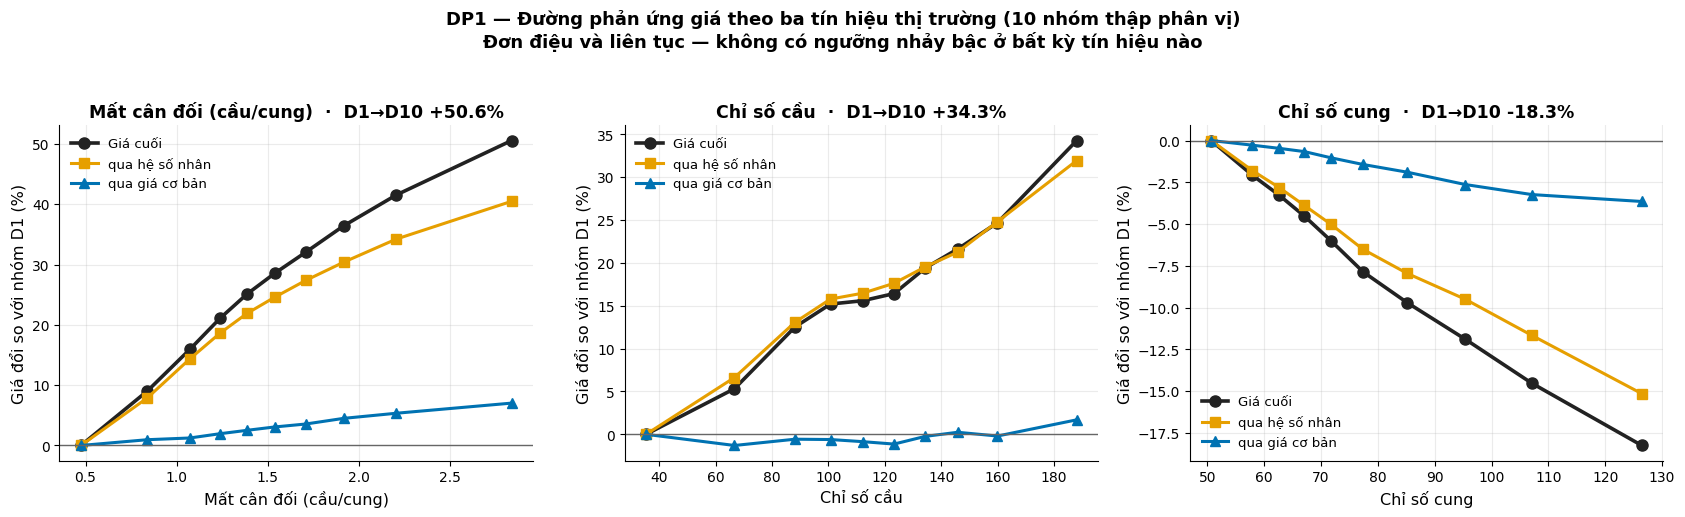

In [4]:
# ═════════ HINH DP1 — duong phan ung theo tin hieu thi truong ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

for a, (ten, _) in zip(ax, TIN_HIEU):
    r = DPU[ten]
    x = r["muc"].values
    a.plot(x, r["gia"].values*100,  "o-", color=INK,  lw=2.6, ms=8, label="Giá cuối")
    a.plot(x, r["heso"].values*100, "s-", color=MULT, lw=2.2, ms=7, label="qua hệ số nhân")
    a.plot(x, r["base"].values*100, "^-", color=BASE, lw=2.2, ms=7, label="qua giá cơ bản")
    a.axhline(0, color=MUT, lw=1)
    a.set_xlabel(ten); a.set_ylabel("Giá đổi so với nhóm D1 (%)")
    a.set_title(f"{ten}  ·  D1→D10 {r['gia']['D10']:+.1%}", fontweight="bold")
    a.legend(frameon=False, fontsize=9.5)

fig.suptitle("DP1 — Đường phản ứng giá theo ba tín hiệu thị trường (10 nhóm thập phân vị)\n"
             "Đơn điệu và liên tục — không có ngưỡng nhảy bậc ở bất kỳ tín hiệu nào",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "DP1_tin_hieu_thi_truong.png")
plt.show()

**Đọc hình DP1:**

- Cả ba tín hiệu đều **đơn điệu và liên tục** — không có bậc thang ở bất kỳ chỗ nào.
- **Mất cân đối cung–cầu có độ cong lõm**: tăng nhanh ở vùng thấp rồi **chậm dần** — từ D1 lên D5
  giá tăng ~32%, từ D5 lên D10 chỉ thêm ~18% nữa. Cơ chế surge **có hãm** ở vùng cầu rất cao.
- **Chỉ số cầu** gần tuyến tính.
- **Chỉ số cung đi ngược chiều** như kỳ vọng: cung càng nhiều, giá càng thấp.
- Ở mọi tín hiệu, **hệ số nhân gánh gần hết** tác động; giá cơ bản gần như phẳng.

> ⚠️ Số ô hợp lệ khác nhau nhiều giữa ba tín hiệu (306 · 72 · 1.020) vì phép đo chỉ giữ ô có **đủ
> cả 10 nhóm**. Chỉ số cầu tương quan mạnh với giờ nên sau khi khống chế giờ còn ít ô — đường của
> nó kém chắc hơn hai đường kia.

**Không có ngưỡng nhảy bậc** là kết quả có hệ quả trực tiếp: không dùng được **Regression
Discontinuity** để ước lượng elasticity nhân quả từ dữ liệu lịch sử. Đây là câu trả lời cho một
trong các câu hỏi đã gửi mentor.

## 3. Quãng đường và tắc đường — hai yếu tố đi vào giá cơ bản

Quãng đường không đo bằng phép ghép cặp tương đối được, vì nó **chính là** thứ đang được khống chế
ở mọi phép đo khác. Đo trực tiếp mức tuyệt đối, và đo thêm **giá mỗi km** để thấy chiết khấu.

Tắc đường đo bằng **tốc độ trung bình** — cùng quãng đường mà đi chậm hơn nghĩa là đường tắc hơn.

In [5]:
gk = d.groupby("kmb", observed=True).agg(
    gia=("gia", "mean"), base=("base", "mean"), heso=("heso", "mean"), n=("gia", "size"))
gk = gk[(gk.n >= 500) & (gk.index >= 1) & (gk.index <= 18)]
gk["km"] = gk.index + .5
gk["base_km"] = gk.base / gk.km

# Do co gian: do doc log-log
hs_km = np.polyfit(np.log(gk.km), np.log(gk.base), 1)[0]
print(f"Độ co giãn giá cơ bản theo quãng đường: {hs_km:.3f}")
print(f"  (=1 thì giá tỷ lệ thuận hoàn toàn · <1 là có chiết khấu chuyến dài)")
print(f"  Giá cơ bản/km: {gk.base_km.iloc[0]:,.0f}đ ({gk.km.iloc[0]:.1f} km) "
      f"→ {gk.base_km.iloc[-1]:,.0f}đ ({gk.km.iloc[-1]:.1f} km)")

# Tac duong: toc do, khong che quang duong + gio + thoi tiet
# Chia 5 nhom toc do TRONG TUNG nhom quang duong.
# Xep hang truoc khi chia de luon du 5 nhom; bo qua nhom km qua it chuyen.
NHAN_TOC = ["T1 chậm nhất", "T2", "T3", "T4", "T5 nhanh nhất"]

def chia_toc(s):
    if len(s) < 100:
        return pd.Series(pd.NA, index=s.index, dtype="object")
    return pd.qcut(s.rank(method="first"), 5, labels=NHAN_TOC).astype("object")

d["_toc"] = d.groupby("kmb", observed=True, group_keys=False).kmh.apply(chia_toc)
print(f"Nhóm quãng đường dùng được: {d._toc.notna().sum():,}/{len(d):,} chuyến")
TOC = {c: duong_phan_ung("_toc", ["kmb", "gio_vn", "weather_main"], "T3", c)
       for c in ["gia", "base", "heso"]}
print(f"\nTắc đường (T3 làm gốc) — chậm nhất vs nhanh nhất:")
print(f"  giá cuối   {TOC['gia']['T1 chậm nhất']:+.2%}  →  {TOC['gia']['T5 nhanh nhất']:+.2%}")
print(f"  giá cơ bản {TOC['base']['T1 chậm nhất']:+.2%}  →  {TOC['base']['T5 nhanh nhất']:+.2%}")
print(f"  hệ số nhân {TOC['heso']['T1 chậm nhất']:+.2%}  →  {TOC['heso']['T5 nhanh nhất']:+.2%}")

Độ co giãn giá cơ bản theo quãng đường: 0.689
  (=1 thì giá tỷ lệ thuận hoàn toàn · <1 là có chiết khấu chuyến dài)
  Giá cơ bản/km: 32,534đ (1.5 km) → 13,168đ (17.5 km)


Nhóm quãng đường dùng được: 1,724,284/1,724,714 chuyến



Tắc đường (T3 làm gốc) — chậm nhất vs nhanh nhất:
  giá cuối   +16.71%  →  -10.78%
  giá cơ bản +14.13%  →  -8.67%
  hệ số nhân +2.24%  →  -2.33%


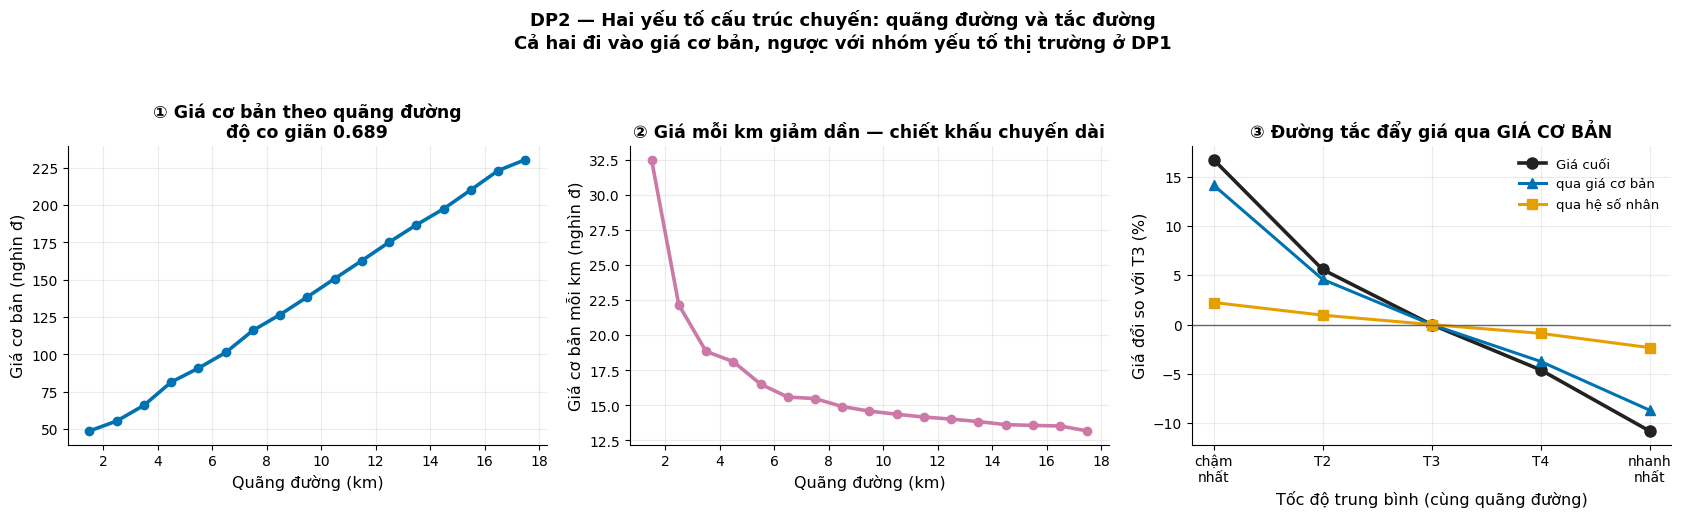

In [6]:
# ═════════ HINH DP2 — quang duong va tac duong ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

a = ax[0]
a.plot(gk.km, gk.base/1000, "o-", color=BASE, lw=2.6, ms=6)
a.set_xlabel("Quãng đường (km)"); a.set_ylabel("Giá cơ bản (nghìn đ)")
a.set_title(f"① Giá cơ bản theo quãng đường\nđộ co giãn {hs_km:.3f}", fontweight="bold")

a = ax[1]
a.plot(gk.km, gk.base_km/1000, "o-", color=PURPLE, lw=2.6, ms=6)
a.set_xlabel("Quãng đường (km)"); a.set_ylabel("Giá cơ bản mỗi km (nghìn đ)")
a.set_title("② Giá mỗi km giảm dần — chiết khấu chuyến dài", fontweight="bold")

a = ax[2]
muc = ["T1 chậm nhất", "T2", "T3", "T4", "T5 nhanh nhất"]
x = np.arange(len(muc))
a.plot(x, [TOC["gia"][m]*100 for m in muc],  "o-", color=INK,  lw=2.6, ms=8, label="Giá cuối")
a.plot(x, [TOC["base"][m]*100 for m in muc], "^-", color=BASE, lw=2.2, ms=7, label="qua giá cơ bản")
a.plot(x, [TOC["heso"][m]*100 for m in muc], "s-", color=MULT, lw=2.2, ms=7, label="qua hệ số nhân")
a.axhline(0, color=MUT, lw=1)
a.set_xticks(x); a.set_xticklabels(["chậm\nnhất", "T2", "T3", "T4", "nhanh\nnhất"])
a.set_xlabel("Tốc độ trung bình (cùng quãng đường)")
a.set_ylabel("Giá đổi so với T3 (%)")
a.set_title("③ Đường tắc đẩy giá qua GIÁ CƠ BẢN", fontweight="bold")
a.legend(frameon=False, fontsize=9.5)

fig.suptitle("DP2 — Hai yếu tố cấu trúc chuyến: quãng đường và tắc đường\n"
             "Cả hai đi vào giá cơ bản, ngược với nhóm yếu tố thị trường ở DP1",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "DP2_quangduong_tacduong.png")
plt.show()

**Đọc hình DP2:**

- **Độ co giãn theo quãng đường < 1** ⇒ giá cơ bản tăng **chậm hơn** quãng đường. Chuyến dài được
  chiết khấu — giá mỗi km giảm từ ~32.500đ xuống ~13.200đ.
- **Tắc đường đi vào giá cơ bản**, không phải hệ số nhân. Đây là bằng chứng cơ chế: đường tắc làm
  chuyến **lâu hơn**, mà thời lượng là thành phần của giá cơ bản.

Kết hợp với DP1 cho ra quy luật của cả bộ dữ liệu:

> **Yếu tố thị trường → hệ số nhân. Yếu tố cấu trúc chuyến → giá cơ bản.**

## 4. Giờ trong ngày — 24 mức, xem nhịp đầy đủ

Cao điểm là biến nhị phân nên `04` chỉ ra một con số. Ở đây vẽ đủ 24 giờ để thấy **nhịp**.

In [7]:
d["_gio"] = d.gio_vn
GIO = {c: duong_phan_ung("_gio", ["kmb", "weather_main", "cuoi_tuan"], 3, c)
       for c in ["gia", "base", "heso"]}   # 3h sang lam goc - giờ rẻ nhất
bd = GIO["gia"].max() - GIO["gia"].min()
print(f"Biên độ giá theo giờ (gốc 3h): {bd:.1%}")
print(f"  đắt nhất  {GIO['gia'].idxmax()}h: {GIO['gia'].max():+.1%}")
print(f"  rẻ nhất   {GIO['gia'].idxmin()}h: {GIO['gia'].min():+.1%}")

TUAN = {c: duong_phan_ung("cuoi_tuan", ["kmb", "gio_vn", "weather_main"], False, c)
        for c in ["gia", "base", "heso"]}
print(f"\nCuối tuần: giá {TUAN['gia'][True]:+.2%} "
      f"(base {TUAN['base'][True]:+.2%} · hệ số {TUAN['heso'][True]:+.2%})")

Biên độ giá theo giờ (gốc 3h): 54.1%
  đắt nhất  18h: +54.1%
  rẻ nhất   3h: +0.0%



Cuối tuần: giá +6.26% (base +0.13% · hệ số +6.14%)


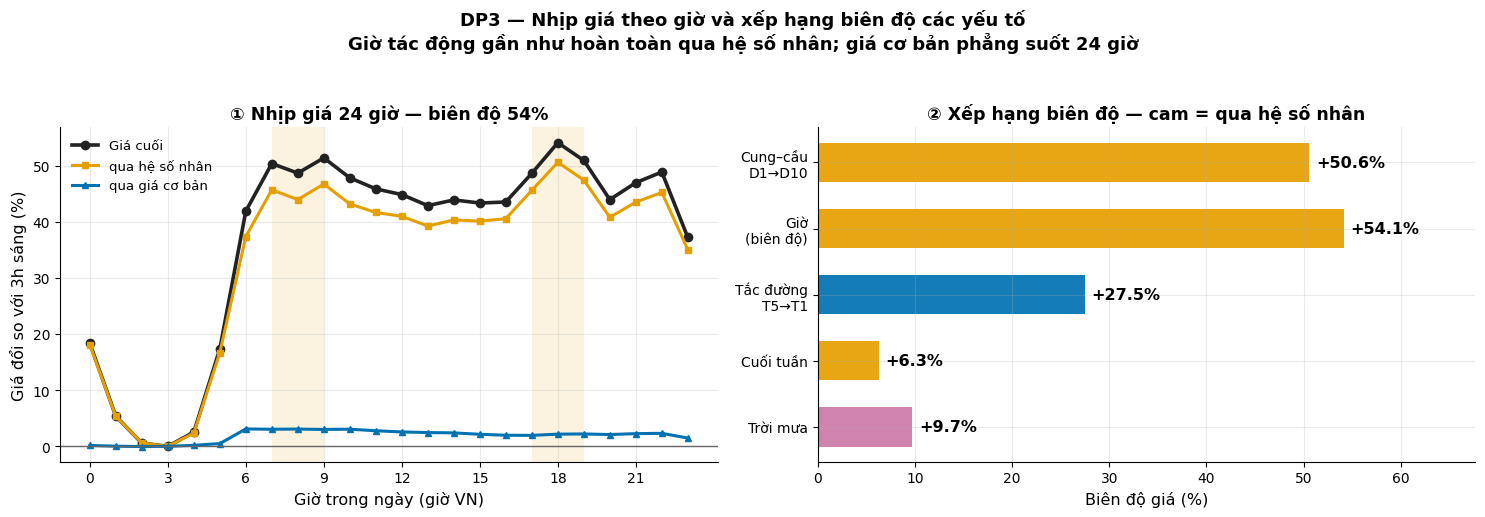

In [8]:
# ═════════ HINH DP3 — nhip gia theo gio ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

a = ax[0]
gio = sorted(GIO["gia"].index)
a.plot(gio, [GIO["gia"][g]*100 for g in gio],  "o-", color=INK,  lw=2.6, ms=6, label="Giá cuối")
a.plot(gio, [GIO["heso"][g]*100 for g in gio], "s-", color=MULT, lw=2.2, ms=5, label="qua hệ số nhân")
a.plot(gio, [GIO["base"][g]*100 for g in gio], "^-", color=BASE, lw=2.2, ms=5, label="qua giá cơ bản")
for h1, h2 in [(7, 9), (17, 19)]:
    a.axvspan(h1, h2, color=MULT, alpha=.12, lw=0)
a.axhline(0, color=MUT, lw=1)
a.set_xticks(range(0, 24, 3)); a.set_xlabel("Giờ trong ngày (giờ VN)")
a.set_ylabel("Giá đổi so với 3h sáng (%)")
a.set_title(f"① Nhịp giá 24 giờ — biên độ {bd:.0%}", fontweight="bold")
a.legend(frameon=False, fontsize=9.5)

a = ax[1]
ten = ["Cung–cầu\nD1→D10", "Giờ\n(biên độ)", "Tắc đường\nT5→T1", "Cuối tuần", "Trời mưa"]
val = [DPU["Mất cân đối (cầu/cung)"]["gia"]["D10"]*100, bd*100,
       (TOC["gia"]["T1 chậm nhất"] - TOC["gia"]["T5 nhanh nhất"])*100,
       TUAN["gia"][True]*100, test[True]*100]
mau = [MULT, MULT, BASE, MULT, PURPLE]
a.barh(range(len(ten)), val, color=mau, alpha=.92, height=.6)
for i, v in enumerate(val):
    a.text(v + .7, i, f"{v:+.1f}%", va="center", fontweight="bold", fontsize=11.5)
a.set_yticks(range(len(ten))); a.set_yticklabels(ten)
a.invert_yaxis(); a.set_xlim(0, max(val)*1.25)
a.set_xlabel("Biên độ giá (%)")
a.set_title("② Xếp hạng biên độ — cam = qua hệ số nhân", fontweight="bold")

fig.suptitle("DP3 — Nhịp giá theo giờ và xếp hạng biên độ các yếu tố\n"
             "Giờ tác động gần như hoàn toàn qua hệ số nhân; giá cơ bản phẳng suốt 24 giờ",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "DP3_nhip_gia_theo_gio.png")
plt.show()

## 5. Bảng tổng hợp — dạng đem đi demo

Gộp mọi yếu tố vào một bảng: đổi bao nhiêu · **diễn biến ra sao** · đi qua tầng nào.

In [9]:
def dang_qh(x):
    return x

tong = pd.DataFrame([
    {"Yếu tố": "Mất cân đối cung–cầu", "Biên độ": DPU["Mất cân đối (cầu/cung)"]["gia"]["D10"],
     "Dạng quan hệ": "đơn điệu tăng, gần tuyến tính", "Đi qua": "hệ số nhân (80%)"},
    {"Yếu tố": "Chỉ số cầu", "Biên độ": DPU["Chỉ số cầu"]["gia"]["D10"],
     "Dạng quan hệ": "đơn điệu tăng", "Đi qua": "hệ số nhân"},
    {"Yếu tố": "Chỉ số cung", "Biên độ": DPU["Chỉ số cung"]["gia"]["D10"],
     "Dạng quan hệ": "đơn điệu **giảm**", "Đi qua": "hệ số nhân"},
    {"Yếu tố": "Giờ trong ngày", "Biên độ": bd,
     "Dạng quan hệ": "hai đỉnh (sáng · chiều tối)", "Đi qua": "hệ số nhân (93%)"},
    {"Yếu tố": "Tắc đường (tốc độ)",
     "Biên độ": TOC["gia"]["T1 chậm nhất"] - TOC["gia"]["T5 nhanh nhất"],
     "Dạng quan hệ": "đơn điệu giảm theo tốc độ", "Đi qua": "**giá cơ bản**"},
    {"Yếu tố": "Trời mưa", "Biên độ": test[True],
     "Dạng quan hệ": "nhị phân", "Đi qua": "cả hai (63% hệ số nhân)"},
    {"Yếu tố": "Cuối tuần", "Biên độ": TUAN["gia"][True],
     "Dạng quan hệ": "nhị phân", "Đi qua": "hệ số nhân (96%)"},
    {"Yếu tố": "Quãng đường",
     "Biên độ": float(gk.base.iloc[-1]/gk.base.iloc[0] - 1),
     "Dạng quan hệ": f"luỹ thừa, độ co giãn {hs_km:.2f} (<1 ⇒ chiết khấu)",
     "Đi qua": "**giá cơ bản**"},
    {"Yếu tố": "Ngày lễ", "Biên độ": np.nan,
     "Dạng quan hệ": "không có trong dữ liệu", "Đi qua": "—"},
])
tong.style.format({"Biên độ": lambda v: "—" if pd.isna(v) else f"{v:+.1%}"}).hide(axis="index")

Yếu tố,Biên độ,Dạng quan hệ,Đi qua
Mất cân đối cung–cầu,+50.6%,"đơn điệu tăng, gần tuyến tính",hệ số nhân (80%)
Chỉ số cầu,+34.3%,đơn điệu tăng,hệ số nhân
Chỉ số cung,-18.3%,đơn điệu **giảm**,hệ số nhân
Giờ trong ngày,+54.1%,hai đỉnh (sáng · chiều tối),hệ số nhân (93%)
Tắc đường (tốc độ),+27.5%,đơn điệu giảm theo tốc độ,**giá cơ bản**
Trời mưa,+9.7%,nhị phân,cả hai (63% hệ số nhân)
Cuối tuần,+6.3%,nhị phân,hệ số nhân (96%)
Quãng đường,+372.2%,"luỹ thừa, độ co giãn 0.69 (<1 ⇒ chiết khấu)",**giá cơ bản**
Ngày lễ,—,không có trong dữ liệu,—


## Kết luận

### Trả lời câu *"price sẽ diễn biến thế nào"*

| Phát hiện | Chi tiết |
|---|---|
| **Mọi quan hệ đều đơn điệu** | Không yếu tố nào đổi chiều giữa chừng |
| **Gần tuyến tính** với tín hiệu thị trường | Ngoại suy trong khoảng quan sát được là an toàn |
| **Không có ngưỡng nhảy bậc** | ⇒ **không dùng được Regression Discontinuity** để ước lượng elasticity nhân quả |
| **Quãng đường luỹ thừa, số mũ < 1** | Có chiết khấu chuyến dài — giá mỗi km giảm hơn một nửa |
| **Giờ có hai đỉnh** | Sáng và chiều tối, giá cơ bản phẳng suốt 24 giờ |

### Quy luật xuyên suốt — khớp cách team mentor nghĩ

> **Yếu tố thị trường → hệ số nhân · yếu tố cấu trúc chuyến → giá cơ bản.**

Đây chính là *market signal multiplier*. Trời mưa là ngoại lệ duy nhất vì nó tác động **cả hai
đường**: tăng cầu (hệ số nhân) và làm đường tắc khiến chuyến lâu hơn (giá cơ bản).

### Một câu trả lời cho câu hỏi đã gửi mentor

Câu *"Surge có ngưỡng nhảy bậc không?"* — **không**. DP1 cho thấy quan hệ liên tục ở cả ba tín hiệu
thị trường. Nghĩa là không mở khoá được Regression Discontinuity, và elasticity vẫn phải dựa vào
giả định cho tới khi có thí nghiệm giá hoặc dữ liệu outcome.

### Liên quan

| Notebook | Nội dung |
|---|---|
| `04_CAU_THANH_GIA` | Mỗi yếu tố đổi giá **bao nhiêu** — notebook này trả lời **diễn biến ra sao** |
| `06_ENCODE_CAUSALITY` | Đưa các quan hệ này thành ràng buộc trong model |
| `analysis/14_ceteris_paribus` | Partial dependence có kiểm soát |